In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']    = (12, 6)
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'primary'  : '#2C3E50',
    'profit'   : '#27AE60',
    'revenue'  : '#2980B9',
    'cost'     : '#E74C3C',
    'warning'  : '#F39C12',
    'highlight': '#8E44AD'
}

DIVISION_COLORS = {
    'Chocolate': '#27AE60',
    'Sugar'    : '#2980B9',
    'Other'    : '#F39C12'
}

In [2]:
df = pd.read_csv('../data/nassau_candy_enriched.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

total_revenue = df['Sales'].sum()
total_profit  = df['Gross Profit'].sum()

print(f"Data loaded: {df.shape[0]} rows")

Data loaded: 6013 rows


### Prepare Pareto Data

In [3]:
# Product level pareto — profit
product_pareto = df.groupby('Product Name')['Gross Profit'].sum()\
                   .sort_values(ascending=False)\
                   .reset_index()

product_pareto.columns = ['Product Name', 'Total_Profit']
product_pareto['Profit_%']            = product_pareto['Total_Profit'] / total_profit * 100
product_pareto['Cumulative_Profit_%'] = product_pareto['Profit_%'].cumsum()
product_pareto['Profit_%']            = product_pareto['Profit_%'].round(2)
product_pareto['Cumulative_Profit_%'] = product_pareto['Cumulative_Profit_%'].round(2)

# Product level pareto — revenue
product_revenue = df.groupby('Product Name')['Sales'].sum()\
                    .sort_values(ascending=False)\
                    .reset_index()

product_revenue.columns = ['Product Name', 'Total_Revenue']
product_revenue['Revenue_%']            = product_revenue['Total_Revenue'] / total_revenue * 100
product_revenue['Cumulative_Revenue_%'] = product_revenue['Revenue_%'].cumsum()
product_revenue['Revenue_%']            = product_revenue['Revenue_%'].round(2)
product_revenue['Cumulative_Revenue_%'] = product_revenue['Cumulative_Revenue_%'].round(2)

# Short names for x axis
def shorten(name):
    return name.replace('Wonka Bar - ', 'WB - ').replace('Wonka Bar -', 'WB -')

product_pareto['Short_Name']  = product_pareto['Product Name'].apply(shorten)
product_revenue['Short_Name'] = product_revenue['Product Name'].apply(shorten)

print("Pareto data ready")
print(product_pareto[['Short_Name', 'Total_Profit', 'Profit_%', 'Cumulative_Profit_%']])

Pareto data ready
                    Short_Name  Total_Profit  Profit_%  Cumulative_Profit_%
0      WB -Scrumdiddlyumptious      11350.00     20.53                20.53
1   WB - Triple Dazzle Caramel      10897.60     19.71                40.24
2   WB - Nutty Crunch Surprise      10311.09     18.65                58.89
3          WB - Milk Chocolate      10062.59     18.20                77.08
4           WB - Fudge Mallows       9732.00     17.60                94.69
5           Lickable Wallpaper       2480.00      4.49                99.17
6                    Wonka Gum        170.95      0.31                99.48
7       Everlasting Gobstopper        104.00      0.19                99.67
8                  Hair Toffee         59.50      0.11                99.78
9                    Kazookles         47.50      0.09                99.86
10        Fizzy Lifting Drinks         27.00      0.05                99.91
11                   SweeTARTS         21.70      0.04                

### Chart 16: Pareto Chart — Profit

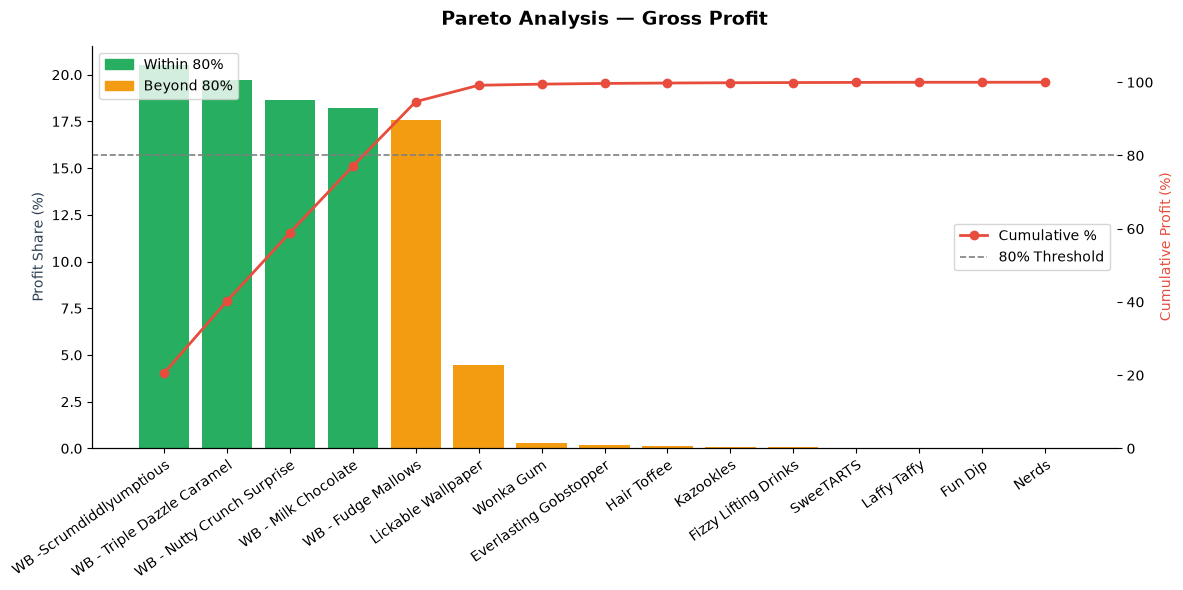

Chart 16 saved


In [4]:
fig, ax1 = plt.subplots()

# Bar chart — individual profit share
bar_colors = [
    COLORS['profit'] if cp <= 80 else COLORS['warning']
    for cp in product_pareto['Cumulative_Profit_%']
]

ax1.bar(product_pareto['Short_Name'], product_pareto['Profit_%'],
        color=bar_colors)

ax1.set_ylabel('Profit Share (%)', color=COLORS['primary'])
ax1.set_xlabel('')
plt.setp(ax1.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')

# Line chart — cumulative % on second y axis
ax2 = ax1.twinx()
ax2.plot(product_pareto['Short_Name'], product_pareto['Cumulative_Profit_%'],
         color=COLORS['cost'], marker='o', linewidth=2, label='Cumulative %')

ax2.axhline(y=80, color='grey', linestyle='--', linewidth=1.2, label='80% Threshold')
ax2.set_ylabel('Cumulative Profit (%)', color=COLORS['cost'])
ax2.set_ylim(0, 110)

ax1.set_title('Pareto Analysis — Gross Profit', fontsize=14, fontweight='bold', pad=15)

ax1.legend(handles=[
    plt.Rectangle((0,0), 1, 1, color=COLORS['profit'],  label='Within 80%'),
    plt.Rectangle((0,0), 1, 1, color=COLORS['warning'], label='Beyond 80%')
], loc='upper left')

ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('../outputs/charts/16_pareto_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 16 saved")

### Chart 17: Pareto Chart — Revenue

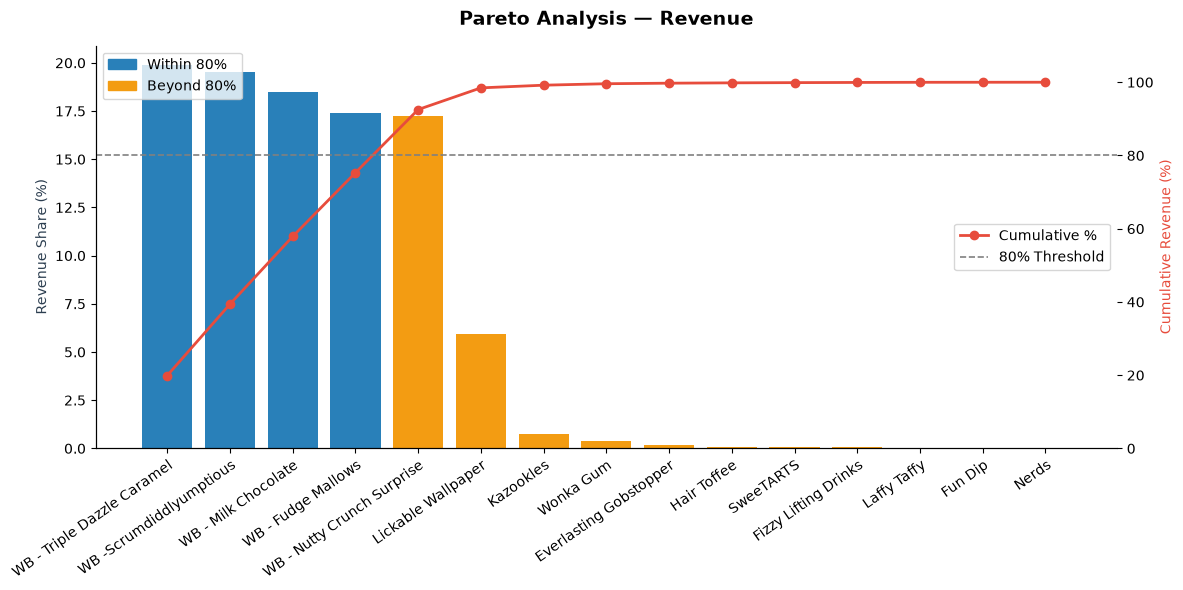

Chart 17 saved


In [5]:
fig, ax1 = plt.subplots()

bar_colors = [
    COLORS['revenue'] if cr <= 80 else COLORS['warning']
    for cr in product_revenue['Cumulative_Revenue_%']
]

ax1.bar(product_revenue['Short_Name'], product_revenue['Revenue_%'],
        color=bar_colors)

ax1.set_ylabel('Revenue Share (%)', color=COLORS['primary'])
ax1.set_xlabel('')
plt.setp(ax1.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')

ax2 = ax1.twinx()
ax2.plot(product_revenue['Short_Name'], product_revenue['Cumulative_Revenue_%'],
         color=COLORS['cost'], marker='o', linewidth=2, label='Cumulative %')

ax2.axhline(y=80, color='grey', linestyle='--', linewidth=1.2, label='80% Threshold')
ax2.set_ylabel('Cumulative Revenue (%)', color=COLORS['cost'])
ax2.set_ylim(0, 110)

ax1.set_title('Pareto Analysis — Revenue', fontsize=14, fontweight='bold', pad=15)

ax1.legend(handles=[
    plt.Rectangle((0,0), 1, 1, color=COLORS['revenue'], label='Within 80%'),
    plt.Rectangle((0,0), 1, 1, color=COLORS['warning'], label='Beyond 80%')
], loc='upper left')

ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('../outputs/charts/17_pareto_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 17 saved")

### Prepare Heatmap Data

In [6]:
# Profit contribution matrix — Product x Division
heatmap_data = df.groupby(['Product Name', 'Division'])['Gross Profit']\
                 .sum().reset_index()

heatmap_pivot = heatmap_data.pivot(
    index='Product Name',
    columns='Division',
    values='Gross Profit'
).fillna(0).round(2)

# Sort by total profit descending
heatmap_pivot['Total'] = heatmap_pivot.sum(axis=1)
heatmap_pivot = heatmap_pivot.sort_values('Total', ascending=False)
heatmap_pivot = heatmap_pivot.drop(columns='Total')

print("Heatmap data ready")
print(heatmap_pivot)

Heatmap data ready
Division                           Chocolate    Other   Sugar
Product Name                                                 
Wonka Bar -Scrumdiddlyumptious      11350.00     0.00    0.00
Wonka Bar - Triple Dazzle Caramel   10897.60     0.00    0.00
Wonka Bar - Nutty Crunch Surprise   10311.09     0.00    0.00
Wonka Bar - Milk Chocolate          10062.59     0.00    0.00
Wonka Bar - Fudge Mallows            9732.00     0.00    0.00
Lickable Wallpaper                      0.00  2480.00    0.00
Wonka Gum                               0.00   170.95    0.00
Everlasting Gobstopper                  0.00     0.00  104.00
Hair Toffee                             0.00     0.00   59.50
Kazookles                               0.00    47.50    0.00
Fizzy Lifting Drinks                    0.00     0.00   27.00
SweeTARTS                               0.00     0.00   21.70
Laffy Taffy                             0.00     0.00   19.84
Fun Dip                                 0.00     0.

### Chart 18: Profit Concentration Heatmap

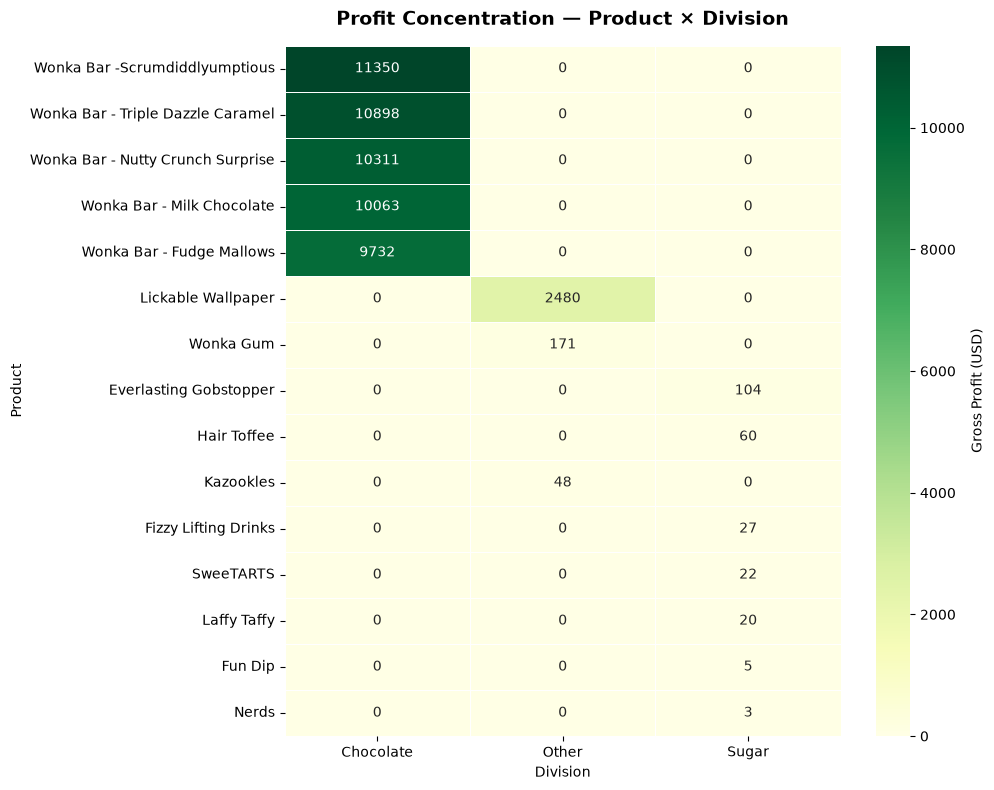

Chart 18 saved


In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGn',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Gross Profit (USD)'},
    ax=ax
)

ax.set_title('Profit Concentration — Product × Division',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Division')
ax.set_ylabel('Product')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/charts/18_profit_concentration_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 18 saved")

### Prepare Dependency Risk Data

In [8]:
# Top 5 vs bottom 10 profit contribution
top5    = product_pareto.head(5).copy()
bottom10 = product_pareto.tail(10).copy()

top5['Group']     = 'Top 5 Products'
bottom10['Group'] = 'Bottom 10 Products'

dependency = pd.concat([top5, bottom10], ignore_index=True)

print("DEPENDENCY RISK")
print(f"Top 5 products profit share    : {top5['Profit_%'].sum():.2f}%")
print(f"Bottom 10 products profit share: {bottom10['Profit_%'].sum():.2f}%")

DEPENDENCY RISK
Top 5 products profit share    : 94.69%
Bottom 10 products profit share: 5.34%


### Chart 19: Dependency Risk Summary

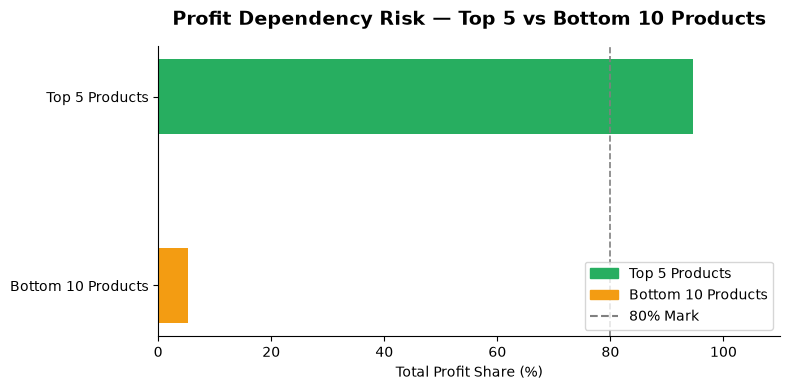

Chart 19 saved


In [9]:
group_summary = dependency.groupby('Group')['Profit_%'].sum().reset_index()
group_summary = group_summary.sort_values('Profit_%', ascending=True)

colors = [COLORS['warning'], COLORS['profit']]

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(group_summary['Group'], group_summary['Profit_%'],
               color=colors, height=0.4)

ax.axvline(x=80, color='grey', linestyle='--', linewidth=1.2)

ax.set_title('Profit Dependency Risk — Top 5 vs Bottom 10 Products',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Profit Share (%)')
ax.set_xlim(0, 110)

ax.legend(handles=[
    plt.Rectangle((0,0), 1, 1, color=COLORS['profit'],  label='Top 5 Products'),
    plt.Rectangle((0,0), 1, 1, color=COLORS['warning'], label='Bottom 10 Products'),
    plt.Line2D([0], [0], color='grey', linestyle='--',  label='80% Mark')
], loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/charts/19_dependency_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 19 saved")